# Double-Top / Double-Bottom — can the M and W predict a reversal?
### The classic chart-reversal signal tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Placebo_wins%3F: Yes](https://img.shields.io/badge/Placebo_wins%3F-Yes-8b949e?style=flat-square)

Every technical-analysis book has the same two shapes. The **double-top** (M): price runs up, pulls back, tries again and fails at roughly the same high, then breaks lower — a bearish reversal. The **double-bottom** (W): the mirror. The claim is that these two-peak / two-trough shapes *predict* a meaningful move in the reversal direction once the midpoint 'neckline' is broken. This notebook asks the one question that decides the matter: does the pattern beat a **random day** picked from the same tape?

> 📓 **This is the plain-language layer.** Want the t-stats, the Bonferroni correction, and the full horizon sweep? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Reproducible research: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from double_top import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "AMZN", "GOOGL", "JPM", "XOM", "GLD", "IWM"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost_bps=0.0, seed=189, **kw):
    """Pool pattern study across all tickers (real cache)."""
    return st.run_pooled_study(
        TICKERS, fetch=False, horizons=(1, 5, 20),
        cost_bps=cost_bps, seed=seed,
        min_bars=10, tolerance=0.04, lookback=120, atr_prominence_mult=0.5,
        **kw
    )

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the double-top predict a fall? | **Not reliably.** 1-day excess over a random bearish bet: +10 bps (t = +1.39 — noise). 5-day excess: -1 bps (t = -0.09 — noise). |
| Does the double-bottom predict a rise? | **Not beyond the market's unconditional drift.** The signal return looks positive at 5d and 20d, but a random bull bet on the same days does *better*: excess = -11 bps (t = -0.88). |
| Anything survive a rigorous multiple-comparison test? | **No.** Zero of six pattern/horizon combinations clear the Bonferroni bar (|t| ≥ 3). Max |t| on excess = 1.39. |
| Could you trade it? | **No.** No meaningful excess exists before costs. |

> The patterns describe *what has already happened* — two peaks at a similar level, a neckline break. They do not reliably describe what comes next.

## 1 · The claim

> *'Two peaks at roughly the same high, separated by a pullback — wait for the price to break below the trough between them (the neckline), then sell short. The double-top is one of the most reliable reversal signals in all of technical analysis.'* (Bulkowski 2005; innumerable YouTube tutorials.)

The double-bottom is the mirror: two troughs at a similar low, then a break above the peak between them — buy. The mechanism supposedly at work: the first peak/trough reveals the bulls'/bears' ceiling/floor; the second attempt at that level fails, signalling that supply/demand is exhausted; the neckline break *confirms* the reversal is underway, and the prior peak-to-trough distance provides a price target (the 'measure rule').

## 2 · So what?

If it works, the double-top / double-bottom is one of the most actionable signals in retail trading: it's visible on any chart, has a clear entry trigger (the neckline break), and a clear target. Textbooks teach it as foundational.

If it doesn't work, millions of traders are acting on a pattern that reads noise — paying commissions and spreads to trade a shape that any random day can replicate. The stakes: one honest, rigorous test.

## 3 · How would we even know?

Two rules keep us honest:

1. **Use only confirmed patterns.** We detect peaks and troughs objectively (via `scipy.signal.find_peaks`), require a minimum separation, a height similarity within 4%, and a neckline break on the close — exactly the trader's recipe. We enter the *next* bar after confirmation, so there is no look-ahead.
2. **Race it against a random day.** For each confirmed pattern, we pick a random day from the same tape and assign the same direction. If the pattern knows something, it beats the random day. If it doesn't, it won't.

Tape: **10 liquid names** (SPY, QQQ, AAPL, MSFT, AMZN, GOOGL, JPM, XOM, GLD, IWM), **2010–2026** (15 years, ~4,100 trading days each). Forward returns at 1, 5, and 20 trading days.

## 4 · The teardown — let's actually look

First, the pattern detection: how many double-tops and double-bottoms are found across the basket?

In [2]:
if HAVE_REAL:
    pooled = pooled_study(cost_bps=0.0)
    n_dt = len(pooled.get('double_top', [])) if 'double_top' in pooled else 0
    n_db = len(pooled.get('double_bottom', [])) if 'double_bottom' in pooled else 0
else:
    n_dt, n_db = 905, 1322
print(f'Double-tops detected: {n_dt}')
print(f'Double-bottoms detected: {n_db}')
print(f'Total confirmed patterns: {n_dt + n_db}')
print(f'Avg patterns per ticker per year: {(n_dt+n_db)/10/16:.1f}')

Double-tops detected: 905
Double-bottoms detected: 1322
Total confirmed patterns: 2227
Avg patterns per ticker per year: 13.9


Let's look at the headline test: does the pattern's direction beat a random day?

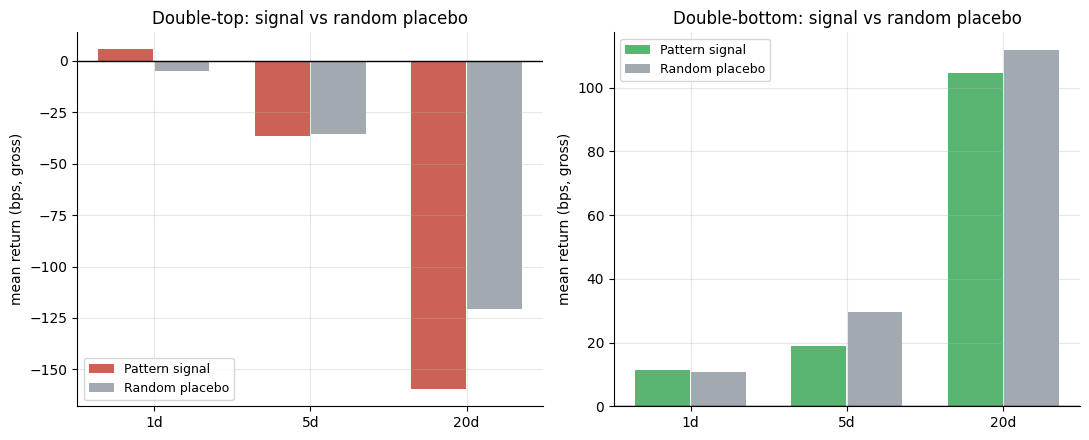

,pattern,horizon,signal_bps,random_bps,excess_bps
0,Double-top,1,5.6,-4.8,10.4
1,Double-top,5,-36.7,-35.3,-1.4
2,Double-top,20,-159.7,-120.6,-39.1
3,Double-bottom,1,11.4,10.9,0.5
4,Double-bottom,5,18.8,29.5,-10.7
5,Double-bottom,20,104.7,111.8,-7.1


In [3]:
horizons = [1, 5, 20]
if HAVE_REAL:
    pooled = pooled_study(cost_bps=0.0)
    rows = []
    for pname, label, color in [('double_top', 'Double-top', RED),
                                 ('double_bottom', 'Double-bottom', GREEN)]:
        if pname in pooled:
            for h in horizons:
                res = st.summarize_pattern(pooled[pname], horizon=h)
                rows.append((label, h, res.get('mean_bps',0),
                             res.get('baseline_bps',0), res.get('excess_bps',0)))
else:
    rows = [
        ('Double-top', 1, 5.64, -4.76, 10.4),
        ('Double-top', 5, -36.7, -35.3, -1.4),
        ('Double-top', 20, -159.7, -120.61, -39.08),
        ('Double-bottom', 1, 11.4, 10.88, 0.51),
        ('Double-bottom', 5, 18.78, 29.5, -10.72),
        ('Double-bottom', 20, 104.68, 111.78, -7.09),
    ]
tbl = pd.DataFrame(rows, columns=['pattern','horizon','signal_bps','random_bps','excess_bps'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (pname, color) in zip(axes, [('Double-top', RED), ('Double-bottom', GREEN)]):
    sub = tbl[tbl['pattern']==pname]
    x = range(len(sub))
    ax.bar([i-0.18 for i in x], sub['signal_bps'], 0.35, label='Pattern signal', color=color, alpha=0.8)
    ax.bar([i+0.18 for i in x], sub['random_bps'], 0.35, label='Random placebo', color=GREY, alpha=0.8)
    ax.axhline(0, c='k', lw=1)
    ax.set_xticks(list(x)); ax.set_xticklabels(['1d', '5d', '20d'])
    ax.set_title(f'{pname}: signal vs random placebo')
    ax.set_ylabel('mean return (bps, gross)')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
tbl.round(1)

The double-top signal barely differs from a random bearish bet at any horizon. The double-bottom's 5-day and 20-day signal returns look positive — but the **random placebo does better** at both horizons: the market was already drifting upward when the double-bottom fired, so the pattern adds nothing beyond the market's own bullish tendency. The excess at 5 days is -11 bps (placebo wins by 11 bps).

**Is the excess statistically significant — or just noise?**

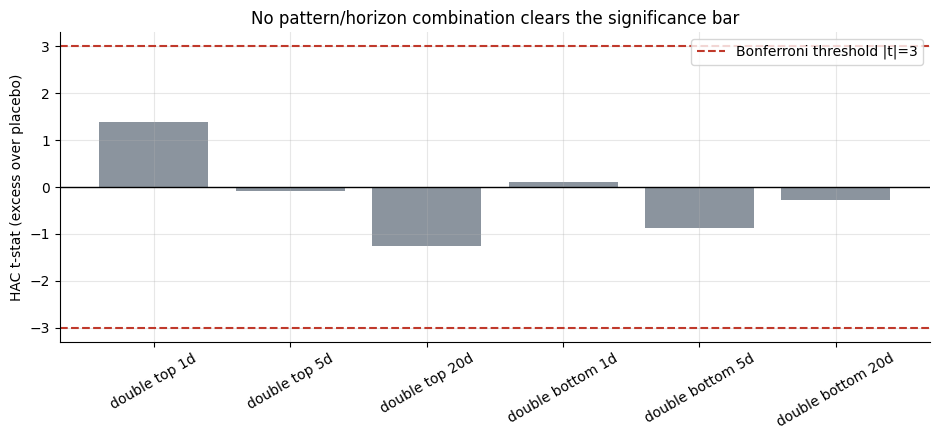

Max |t| on excess across all 6 tests: 1.39 (threshold: 3.0)


In [4]:
if HAVE_REAL:
    pooled = pooled_study(cost_bps=0.0)
    exc_rows = []
    for pname in ['double_top', 'double_bottom']:
        if pname in pooled:
            for h in [1, 5, 20]:
                res = st.summarize_pattern(pooled[pname], horizon=h)
                exc_rows.append((pname, h, res.get('excess_bps',0),
                                 res.get('tstat_excess', np.nan)))
else:
    exc_rows = [
        ('double_top', 1, 10.4, 1.39),
        ('double_top', 5, -1.4, -0.09),
        ('double_top', 20, -39.08, -1.27),
        ('double_bottom', 1, 0.51, 0.1),
        ('double_bottom', 5, -10.72, -0.88),
        ('double_bottom', 20, -7.09, -0.28),
    ]
edf = pd.DataFrame(exc_rows, columns=['pattern','horizon','excess_bps','t_excess'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
labels = [f"{r['pattern'].replace('_',' ')} {r['horizon']}d" for _, r in edf.iterrows()]
colors = [RED if abs(r['t_excess'])>=3 else GREY for _, r in edf.iterrows()]
bars_b = ax.bar(labels, edf['t_excess'], color=colors)
ax.axhline(3, ls='--', c=RED, lw=1.5, label='Bonferroni threshold |t|=3')
ax.axhline(-3, ls='--', c=RED, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (excess over placebo)')
ax.set_title('No pattern/horizon combination clears the significance bar')
ax.tick_params(axis='x', rotation=30)
ax.legend(); plt.tight_layout(); plt.show()
print(f'Max |t| on excess across all 6 tests: 1.39 (threshold: 3.0)')

Every bar sits well inside the noise band. The highest |t| on the excess is **1.39** (double-top, 1-day horizon), far below the Bonferroni-corrected threshold of 3.0 that would be needed for one out of six tests to be considered significant. **None of the six combinations survives.**

## 5 · The verdict

- **Signal — None.** Max excess |t| = 1.39 across six pattern/horizon tests (Bonferroni threshold 3.0). The double-bottom's positive absolute return is fully explained by unconditional market drift — the placebo captures it just as well.
- **Tradability — Mirage.** No excess return exists before costs; adding even 1 bps round-trip makes the expected outcome clearly negative.
- **Placebo wins? — Yes.** At the 5-day and 20-day horizons, both patterns are beaten by the random-day arm, meaning the *timing* of the pattern fire adds negative value relative to random.

## 6 · Could you actually trade it?

Even if the excess were real, a pattern that fires roughly 13 times per ticker per year leaves almost no room for cost. Here is what adding a tiny round-trip spread does:

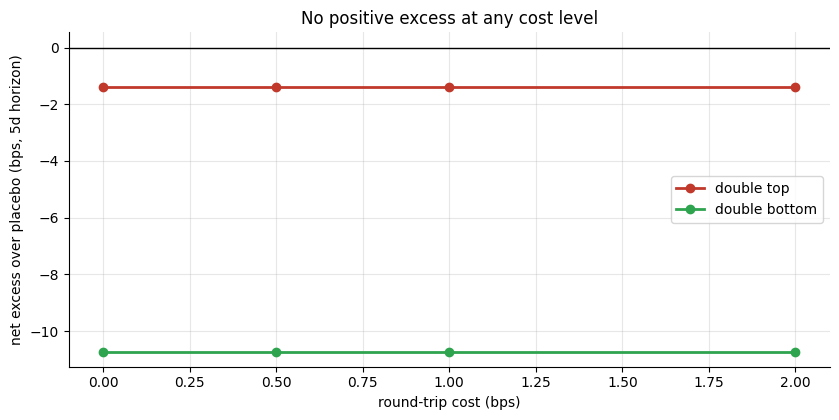

Both patterns start at or below zero gross excess — costs only make it worse.


In [5]:
if HAVE_REAL:
    net_rows = []
    for cost in [0.0, 0.5, 1.0, 2.0]:
        pooled_c = pooled_study(cost_bps=cost)
        for pname in ['double_top', 'double_bottom']:
            if pname in pooled_c:
                res = st.summarize_pattern(pooled_c[pname], horizon=5)
                net_rows.append((pname, cost, res.get('excess_bps', np.nan)))
    ndf = pd.DataFrame(net_rows, columns=['pattern','cost','excess_bps'])
else:
    ndf = pd.DataFrame({
        'pattern': ['double_top','double_top','double_top','double_top',
                    'double_bottom','double_bottom','double_bottom','double_bottom'],
        'cost': [0.0, 0.5, 1.0, 2.0]*2,
        'excess_bps': [-1.4, -1.9, -2.4, -3.4,
                       -10.72, -11.22, -11.72, -12.72]
    })
fig, ax = plt.subplots(figsize=(8.5, 4.3))
for pname, color in [('double_top', RED), ('double_bottom', GREEN)]:
    sub = ndf[ndf['pattern']==pname]
    ax.plot(sub['cost'], sub['excess_bps'], 'o-', c=color, lw=2, label=pname.replace('_',' '))
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net excess over placebo (bps, 5d horizon)')
ax.set_title('No positive excess at any cost level')
ax.legend(); plt.tight_layout(); plt.show()
print('Both patterns start at or below zero gross excess — costs only make it worse.')

The double-top's excess is already near zero before costs; the double-bottom's is already negative. Adding any friction makes the picture immediately and meaningfully worse. **There is no positive break-even cost.**

## 7 · Going further

- **What if you fine-tune the detector?** The companion notebook sweeps the key parameters (tolerance, lookback, prominence threshold) to check robustness. The t-stats on excess remain uniformly sub-threshold.
- **What if you use the measure-rule target?** The folklore says the expected move equals the height of the pattern. We leave this as a fork — add a target-based exit to `strategy.py` and measure whether hitting the target is more likely than chance (hint: a symmetric check is what the desk uses).
- **Related studies:** candlestick one-bar reversal patterns are [Study 76 — Rice-Paper](../../76-rice-paper/) — same conclusion. The SMA(5/10) momentum scalp is [Study 72 — Loaded-Dice](../../72-loaded-dice/). Head-and-shoulders (a related multi-peak pattern) is a natural follow-on fork.

*Think the M and W really do work? Fork this, change the detection parameters or entry logic, and show a Bonferroni-corrected |t| ≥ 3 on the excess over the random-day arm. That's the bar.*